<a href="https://colab.research.google.com/github/jmcardenas8/Notebooks-Pregrado-Astronomia/blob/main/Mecanica-celeste/Tarea1_Ctes_Mov_SistemaSolar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p>
<img src="https://drive.google.com/uc?id=1ZHUKcwzA5c-PKUwoGmBG3TsHk6TmZ-Y0" align="left" width="250">
</p><p><br>

<h1><b><center>Mecánica Celeste</center></b></h1>
<h2><b><center>Prof. Jorge I. Zuluaga</center></b></h1>
<h2><b><center>Tarea 1</center></b><h2>
<h3><b><center>Constantes de movimiento del sistema solar</center></b><h3>
<h5><center><b>Asignada</b>: 15 de Agosto de 2023</center><h5>
<h5><center><b>Entrega</b>: 29 de Agosto de 2023</center><h5>
</p>

<hr/>
<b>Nombre</b>: Juan Manuel Cardenas
<br/>
<b>Cédula</b>: 1002587562
<br/>
<b>Última actualización</b>: 29-8-23
<hr/>
<br>

####**Objetivo**:
El objetivo de esta tarea es poner a prueba los resultados vistos en clase sobre las constantes en el problema de los N-cuerpos, en este caso aplicados al sistema solar.  Para ello usaremos el sistema de datos del JPL Horizons y el paquete `astroquery`.


In [ ]:
# librerias
!pip install -q pymcel  # libreria general del profe
import plotly.graph_objs as go # grafic 3d interactive
import spiceypy as spy # Datos planetarios
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from astroquery.jplhorizons import Horizons # efemerides
from astropy import constants as cte # constantes
from tqdm import tqdm # control de tiempos


# Carga web para datos planetarios de masa y µ
cspice=!wget https://naif.jpl.nasa.gov/pub/naif/generic_kernels/pck/gm_de440.tpc -O gm_de440.tpc
spy.furnsh('gm_de440.tpc') # Carga kernels

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 16.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 888.9/888.9 kB 22.2 MB/s eta 0:00:00


In [ ]:
# Parametros y constantes importantes
au    = cte.au.value   # [m]
G     = cte.G.value    # [m^3/s^2*kg]
G_km  = G/(1000**3)    # [km^3/s^2*kg]
d_2_s = 24*60*60       # dias a seg [s]
µ_sun = cte.GM_sun.value     # [m^3/s^2]
µ_sun_km = µ_sun/(1000**3)  # [km^3/s^2]
rad = 180/np.pi # conversion de [°] a [rads]

# unidades canonicas (G= 1[au^3/τ^2*m_sun])
m_sun = cte.M_sun.value           # masa [m_sun kg]
τ =(au**3/(G*m_sun))**0.5 / d_2_s # tiempo [τ]


###**Desarrollo**:

#### **Astroquery y SPICE**

1. Obtener las masas, posiciones y velocidades de los planetas del sistema solar (8 planetas) y del Sol durante 20 años (por ejemplo entre 2000 y 2020), cada 3 meses. Use para ello Astroquery y SPICE (para las masas).

A continuacion se definen los nombres, las $I$d de todos los objetos a estudiar (el sol y los planetas), se extrae el valor de µ de cada uno mediante Spice, con el cual, dividiendo por la constante de gravitacion universal se obtiene la masa de los objetos y se transforman sus unidades a *unidades canonicas*, donde:

> $\left\{\begin{matrix}
U_l = & 1 [au]      \\
U_t = & 1 [τ] & ≈ 58.13 [d]  \\
U_m = & 1 [M_{\odot}]  
\end{matrix}\right.$

Por lo que la constante de gravitacion toma el valor: $G=1 [au^3/τ^2*M_{\odot}]$. Luego, para el intervalo de tiempo ($2000$-$2020$) con pasos de $30$ dias, se procede a extraer los vectores de cada uno de los objetos, donde se guarda el vector posicion $\vec r[x,y,z]$, velocidad $\vec v[vx,vy,vz]$, el tiempo $t$ en años que servirá como eje dependiente en las graficas, y el tiempo en dias julianos, que en unidades canonicas se empleará en la ultima ecuacion de cuadratura (integral trivial del momento lineal)

In [ ]:
# listas
names  = ['sol','Mercurio','Venus','Tierra','Marte','Jupiter','Saturno','Urano','Neptuno']
id_obj = [10,199,299,399,499,599,699,799,899] # id
µ_obj  = []     # µ = MG
obj    = []     # vectores
n = len(id_obj) # tamaño del sistema


# Masa y µ de los objetos
for i in range(n-1):
  µ_obj.append( spy.bodvrd(f'{i+1}99','GM',1) [1][0] ) # µ [km^3/s^2]            # se obtiene µ de cada planeta de cspice

µ_obj = [µ_sun_km] + µ_obj       # µ [km^3/s^2]                                  # se agrega (concatena) µ del sol a la lista
m_obj  = np.array( µ_obj )/G_km  # masa [kg]                                     # se obtiene la masa de µ dividiendo por G en km^3
m_obj  = m_obj/m_sun             # masa canonica [m_sun]                         # se pasa la masa a unidades canonicas


# Vectores de los objetos                                                        # vectores de cada objeto desde astroquery
for i in tqdm(range(n)):
  obj.append( Horizons(id= id_obj[i], location ='@0',
                   epochs=dict(start ='2000-01-01 00:00:00',
                               stop = '2020-01-01 00:00:00',
                               step = '30d')).vectors().to_pandas() )

# vectores pos y vel en [unid canonicas]
r = [ obj[i][['x','y','z']]    for i in range(n) ]      # [au]
v = [ obj[i][['vx','vy','vz']]*τ for i in range(n) ]    # [au/τ]


# intervalo de tiempo
time = obj[0]['datetime_str'] # [años]
t = [pd.to_datetime( time[k][3:] ) for k in range(len(time))] # [años]           # elimina el "A.D." del inicio de cada tiempo
jd_τ = (obj[0]['datetime_jd'] - obj[0]['datetime_jd'][0]) /τ  # [τ]              # dias a partir de la fecha inicial

100%|██████████| 9/9 [00:08<00:00,  1.01it/s]


#### 2. Para cada punto en el tiempo calcular:

   - El momentum lineal de cada cuerpo
   $ m_{i} \dot{\vec{r}}_{}=\vec{P}_{CM} $


   - El momentum angular de cada cuerpo $ m_{i} \vec{r} \times \dot{\vec{r}} = \vec{L}$

   - La energía cinética de cada cuerpo $ K= \frac{m_{i} \vec{v}^{2} }{2}  $

   - La energía potencial gravidtacional de todo el sistema $ U=-\sum_{i<j}\sum_{j\neq i} \frac{G m_{i}m_{j}}{r_{ij}} $

Esta seccion se basó basicamente en dos ciclos ```for ```. El primero corre sobre cada uno de los cuerpos del sistema solar a estudiar, que bastó para calcular los valores relacionados con los momentos lineal y angular por las propiedades de los arreglos y del DataFrame de pandas. El segundo ciclo fue necesario para las energias, para poder aplicar el producto punto (en cinetica), y porque la Potencial requeria de dos distintos contadores pues su definicion se da entre $2$ cuerpos. Se calcularon y se guardaron los valores para cada cuerpo del sistema en listas (tamaño $9$), y a su vez dentro de estas para cada instante de tiempo ($244$ instantes); en el caso de ser vectoriales en dataframes ($244$ x $3$), y para los escalares ($244$ x $1$).

In [ ]:
P = [] # momento lineal individual
L = [] # momento angular individual
U = [] # E. potencial
Ug= [] # E. potencial (metodo2)
MRcm0 = [] # integral del momento lineal
K = np.zeros((n, len(t))) # E. cinetica
KK =np.zeros((n, len(t)))

for i in range(n):

  # M. Lineal                                                                    # P = mv  [m_sun*au/τ]
  p_i = np.array( m_obj[i] * v[i]  )
  P.append( pd.DataFrame( {'px':p_i[:,0], 'py':p_i[:,1], 'pz':p_i[:,2]}) )


  # M. Angular                                                                   # L = mr x v  [m_sun*au^2/τ]
  L_i = np.cross( m_obj[i] * r[i] , v[i]   )
  L.append( pd.DataFrame( {'Lx':L_i[:,0], 'Ly':L_i[:,1], 'Lz':L_i[:,2]})  )


  # Integral de P                                                                # MR_cm0 = m(r-vt)  [m_sun*au]
  MR_i = m_obj[i] *( r[i]- jd_τ[i] * v[i].values )
  MRcm0.append(pd.DataFrame({'MRcm0_x':MR_i['x'],                                   # .values toma solo los valores del dataframe como un array
                             'MRcm0_y':MR_i['y'],
                             'MRcm0_z':MR_i['z']}))

  # Cinetica                                                                     # K = mv^2/2 [m_sun*au^2/τ^2]
  for k in range(len(t)): # toma cada fila
    K[i][k] =  0.5*m_obj[i] *(np.dot( v[i].iloc[k] , v[i].iloc[k] ))                # guarda cinetica de cada tiempo para cada cuerpo
                                                                                    # .iloc toma cada fila
                                                                                    # otro forma:  puede ser np.dot( v[i] , v[i].T )
                                                                                    # otra forma: K[i][k] =  0.5*m_obj[i] *(np.linalg.norm( v[i].iloc[k] ))**2
  # Potencial
  for j in range(n):
    # metodo 1 (1/2)
    if i!=j:
      U_ij = -0.5* m_obj[i]*m_obj[j] / np.linalg.norm(r[i]-r[j], axis=1)         # U = -Gmimj/rij  [m_sun au^2 / τ^2]
      U.append(U_ij)

   # metodo 2 general
    if i!=j and i<j:
      U_ijg = - m_obj[i]*m_obj[j] / np.linalg.norm(r[i]-r[j], axis=1)
      Ug.append(U_ijg)

In [ ]:
# prueba de todas las combinaciones para U en el metodo 2
# a=[]
# for i in range(n):
#   for j in range(n):
#     if i!=j and i<j:
#       a.append([i,j])
# a

#### 3. Usando el valor de cada una de las cantidades anteriores vamos a calcular el valor de las cuadraturas del sistema:

- Calcular el **Momentum Lineal** total (3 cuadraturas)
  $$ \sum_{i}m_{i} \dot{\vec{r}}_{i}=\vec{P}_{CM} $$

- Calcular el **Momentum angular** total (3 cuadraturas)
     
  $$ \sum_{i} m_{i} \vec{r}_{i} \times \dot{\vec{r}}_{i} = \vec{L}$$

- Calcular la **Energía total** (1 cuadratura)
$$ K + U= \sum_{i}\frac{m_{i} \vec{v}_{i}^{2} }{2}  -\sum_{i<j}\sum_{j\neq i} \frac{G m_{i}m_{j}}{r_{ij}} = E $$

- Calcular la **integral del momentum lineal** total (3 cuadraturas)

$$ \sum_{i} m_i ( \vec{r}_i -  \dot{\vec{r}}_i t ) = M \vec{R}_{cm} $$



Para obtener los valores totales se requiere realizar una suma sobre la lista en la que se encuentran los datos calculados anteriormente para cada cuerpo, por lo que se empleó la funcion ```sum()```. Ademas para comparar las dos formas de energia potencial se incluyeron dos variables para ambas energias mecanicas

In [ ]:
# momento Lineal total
Pt = sum(P)

# momento Angular total
Lt = sum(L)

# cinetica, potencial y mecanica total
Kt = sum(K)
Ut = sum(U) ; Utg = sum(Ug)
Et = Kt + Ut
Etg = Kt + Utg

# Integral de m.lineal (pos CM inicial)
MR0 = sum(MRcm0)

#### 4. Gráficos de las 10 cuadraturas.

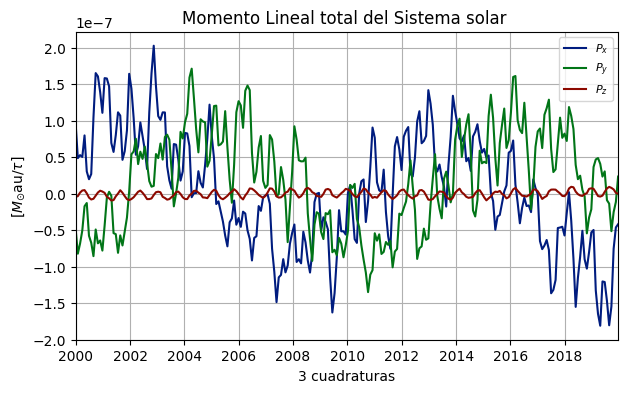

In [ ]:
# grafica momento lineal: 3 cuadraturas                                          # otros style:
plt.style.use('seaborn-v0_8-dark-palette')                                       # seaborn-colorblind, seaborn-v0_8, classic, seaborn-v0_8-dark-palette
plt.figure(figsize=(7,4))
plt.plot(t, Pt['px'], label='$P_{x}$')
plt.plot(t, Pt['py'], label='$P_{y}$')
plt.plot(t, Pt['pz'], label='$P_{z}$')
plt.title('Momento Lineal total del Sistema solar ')
plt.ylabel('[$M_{\odot}$au/$τ$]')
plt.xlabel('3 cuadraturas')
plt.legend(fontsize=8)
plt.xlim(t[0], t[-1])
plt.grid()

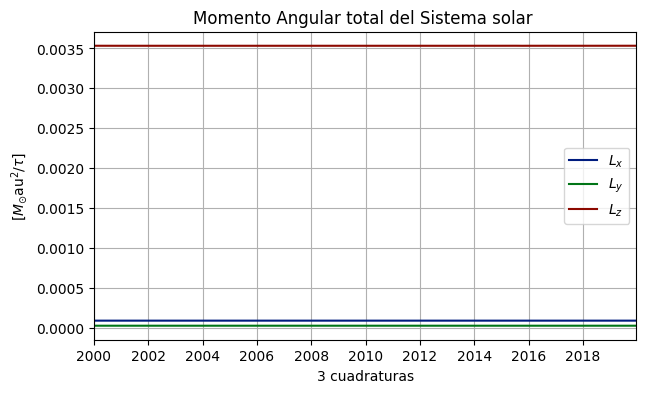

In [ ]:
# grafica momento angular: 3 cuadraturas
plt.figure(figsize=(7,4))
plt.plot(t, Lt['Lx'], label='$L_{x}$')
plt.plot(t, Lt['Ly'], label='$L_{y}$')
plt.plot(t, Lt['Lz'], label='$L_{z}$')
plt.title('Momento Angular total del Sistema solar ')
plt.ylabel('[$M_{\odot}$au$^{2}$/$τ$]')
plt.xlabel('3 cuadraturas')
plt.legend(fontsize=10)
plt.xlim(t[0], t[-1])
plt.grid()

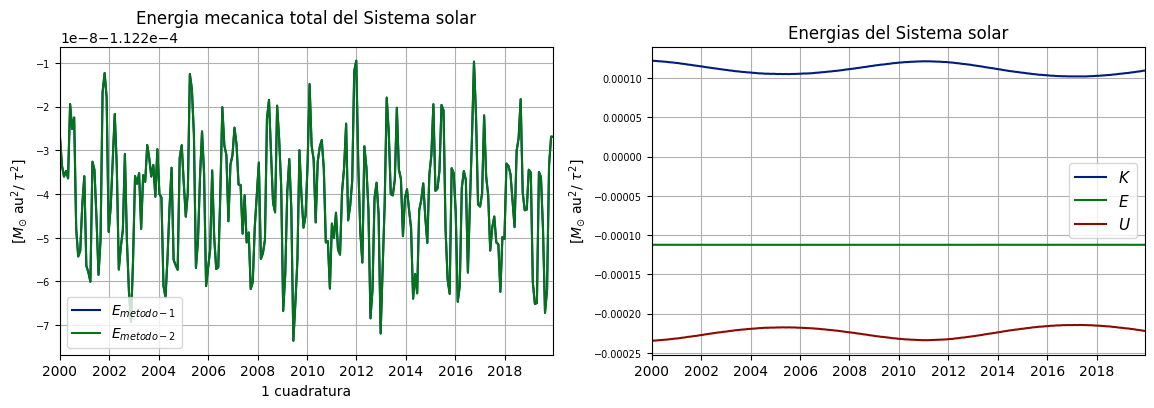

In [ ]:
# Grafica Energia total
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(14,4))

# Energia total
ax[0].set_title('Energia mecanica total del Sistema solar')
ax[0].plot(t, Et, label='$E_{ metodo-1}$')
ax[0].plot(t, Etg, label='$E_{ metodo-2}$')
ax[0].set_ylabel('[$M_{\odot}$ au$^{2}$/ $τ^{2}$]')
ax[0].set_xlim(t[0], t[-1])
ax[0].set_xlabel('1 cuadratura')
ax[0].grid()
ax[0].legend()
ax[0].tick_params(axis='y', labelsize=7)

# Energia cinetica, potencial y mecanica
ax[1].set_title('Energias del Sistema solar')
ax[1].plot(t, Kt, label='$K$')
ax[1].plot(t, Et, label='$E$')
ax[1].plot(t, Ut, label='$U$')
ax[1].set_ylabel('[$M_{\odot}$ au$^{2}$/ $τ^{2}$]')
ax[1].set_xlim(t[0], t[-1])
ax[1].grid()
ax[1].legend(fontsize=11)
ax[1].tick_params(axis='y', labelsize=7)

la energia potencial calculada por los dos metodos, sumada mas la energia cinetica da el mismo resultado, por eso las curvas se sobreponen en la grafica izquierda. esta parece presentar ruido local pero con una escala diferente se evidencia la tendencia constante de esta energia mecanica total $E$.

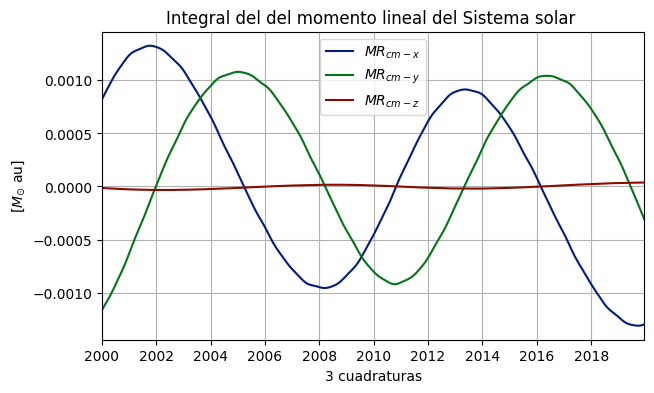

In [ ]:
# grafica integral de momento lineal: 3 cuadraturas
plt.figure(figsize=(7,4))
plt.plot(t, MR0['MRcm0_x'], label='$MR_{cm-x}$')
plt.plot(t, MR0['MRcm0_y'], label='$MR_{cm-y}$')
plt.plot(t, MR0['MRcm0_z'], label='$MR_{cm-z}$')
plt.title('Integral del del momento lineal del Sistema solar ')
plt.ylabel('[$M_{\odot}$ au]')
plt.xlabel('3 cuadraturas')
plt.legend(fontsize=10)
plt.xlim(t[0], t[-1])
plt.grid()


#### 5. Angulo respecto al **plano invariable de Laplace**
El momentum angular total del sistema solar define el Plano de Laplace del sistema. El momentum angular de cada uno de los cuerpos del sistema solar define la inclinación de la órbita osculatriz del cuerpo respecto al plano de Laplace. Calcular, para cada tiempo, el ángulo entre el plano de Laplace y la órbita osculatriz de cada cuerpo (incluyendo el Sol).

Ayuda: el ángulo entre dos vectores se calcula usando la propiedad del producto punto

$$ \vec{L'} \cdot \vec{L_{obj}}  = L' L_{obj} cos(θ)$$
$$ θ = cos^{-1}(\frac{ \vec{L'}\cdot \vec{L_{obj}} } {L'L_{obj}} ) $$



In [ ]:
θ = np.zeros((n,len(t)))

for i in range(n):
  for k in range(len(t)):
    θ[i][k]= np.arccos( np.dot(Lt.iloc[k],L[i].iloc[k]) / (np.linalg.norm(Lt.iloc[k])*np.linalg.norm(L[i].iloc[k])))

θ = θ*rad  # pasando [rad] a [°]

#### 6. Gráfico del ángulo de la órbita osculatriz de cada cuerpo como función del tiempo.


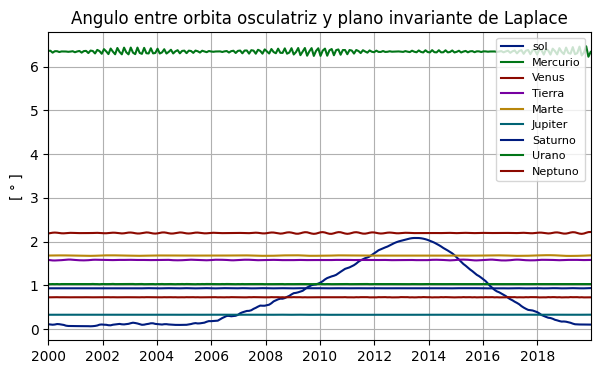

In [ ]:
plt.figure(figsize=(7,4))
for i in range(n):
  plt.plot(t, θ[i], label=f'{names[i]}')

plt.title('Angulo entre orbita osculatriz y plano invariante de Laplace')
plt.ylabel('[ ° ]')
plt.legend(fontsize=8)
plt.xlim(t[0], t[-1])
plt.grid()

la mayoria de las inclinaciones tienden a ser constantes (si se le hace un zoom individual a cada curva estas varian un poco) a exepcion de la del sol, que tiene picos cada 12 años aproximadamente, si se extiende el intervalo de tiempo se pueden observar mas, por ejemplo hasta 2060 se observan 3 picos de este tipo

#### 7. Valor promedio de la inclinación orbital de cada planeta en grados respecto al plano invariante de Laplace.


In [ ]:
print('Inclinacion promedio de la orbita osculatriz respecto al plano invariante de laplace:')
θ_prom=[]

for i in range(n):
  θ_prom.append(np.mean(θ[i]))
  print(f' {names[i]}: {θ_prom[i]:.4}° ')

Inclinacion promedio de la orbita osculatriz respecto al plano invariante de laplace:
 sol: 0.7331° 
 Mercurio: 6.344° 
 Venus: 2.196° 
 Tierra: 1.578° 
 Marte: 1.68° 
 Jupiter: 0.3268° 
 Saturno: 0.9319° 
 Urano: 1.028° 
 Neptuno: 0.7265° 


Los valores angulares obtenidos de inclinacion de la orbita osculatriz respecto al plano invariable para cada planeta concuerdan con los datos de la literatura, y se evidencia que el valor promedio de inclinacion mas baja es la de jupiter $ 0.3268° $, mientras la inclinacion mas elevada es la de mercurio $6.344°$.
<br>

- plano invariable, inclinations table: https://es.wikipedia.org/wiki/Plano_invariable#cite_note-meanplane-1

- Tabla Mean plane osculating elements: https://web.archive.org/web/20111121100544/http://home.comcast.net/~kpheider/Mean142k4.gif

<br> <br>

#### 8. ¿El sistema solar cumple el **teorema del virial**?
Para que un sistema sea ligado, o esté viralizado se debe cumplir alguna de las siguientes condiciones, que son equivalentes:

$$ -2\left\langle K \right\rangle = \left\langle U \right\rangle  $$
$$ E = -\left\langle K \right\rangle  $$

acontinuacion se calculan los promedios para la energia potencial y cinetica total

In [ ]:
print(f'-2<k> = {-2*np.mean(Kt):.8f}') # imprime valor con 8 cfs
print(f'<U> = {np.mean(Ut):.8f}')

-2<k> = -0.00022235
<U> = -0.00022342


In [ ]:
# error absoluto entre ambos valores
err_abs = np.abs(-2*np.mean(Kt) - np.mean(Ut))
print(f'El error absoluto entre ambos es: {err_abs:.8f}')

El error absoluto entre ambos es: 0.00000107


In [ ]:
# 2U + U = 0
print(f'El valor 2<k>+<U>={2*np.mean(Kt) + np.mean(Ut)}')

El valor 2<k>+<U>=-1.0664035971419872e-06


Se encuentra que si se cumple el teorema del virial para el sistema solar en el periodo de tiempo seleccionado de 20 años, pues se cumple con una buena exactitud la relacion $ -2\left\langle K \right\rangle =\left\langle U \right\rangle $

<br><br>
____

**Resultados esperados**:

- Este notebook con el procedimiento debidamente comentado.

- Gráficos mínimos:
  - Gráfico de las 10 cuadraturas normalizadas (divididas por el valor para el Sol).

  - Gráfico de la inclinación de la órbita osculatriz de cada planeta y el Sol.

- Datos mínimos:
  - Valor de la inclinación orbital de cada planeta

____



Gráficos opcionales:

  - Gráfico de las órbitas de los planetas.

  Se realizaron las graficas con los mismos datos en el mismo intervalo de tiempo, y como este intervalo es de apenas 20 años algunos planetas no han alcanzado a cumplir una orbita completa. el grafico con las orbitas completas fue resuelto en el notebook del problem set 1 del taller.

In [ ]:
# grafica del sistema solar en el intervalo de tiempo de 20 años
trazas = [] # [sol[r], mercurio[r], venus[r],...]

# Crea trazas para cada planeta con posiciones
for i in tqdm(range(n)): # r_planet = [mercur[x,y,z], venus[x,y,z]...
  trace = go.Scatter3d(x= r[i]['x'],
                       y= r[i]['y'],
                       z= r[i]['z'],
                       mode = 'lines', name = names[i])
  trazas.append(trace) # agrega las trazas en lista

# Grafica
fig = go.Figure(trazas) # Crea figura con trazas
fig.update_layout(scene=dict(  # Configuracion de figura
    xaxis_title='X [ua]',
    yaxis_title='Y [ua]',
    zaxis_title='Z [ua]',
    zaxis=dict(range=[-10, 10])),
    title='Sistema Solar 3D')
fig.show()

# referencia: como hacer graficas 3d interactivas (plotly.graph_objs)
# https://www.geeksforgeeks.org/3d-scatter-plot-using-graph_objects-class-in-plotly-python/

100%|██████████| 9/9 [00:00<00:00, 174.71it/s]



  - Gráfico de las magnitudes del momentum lineal y angular total como función del tiempo.


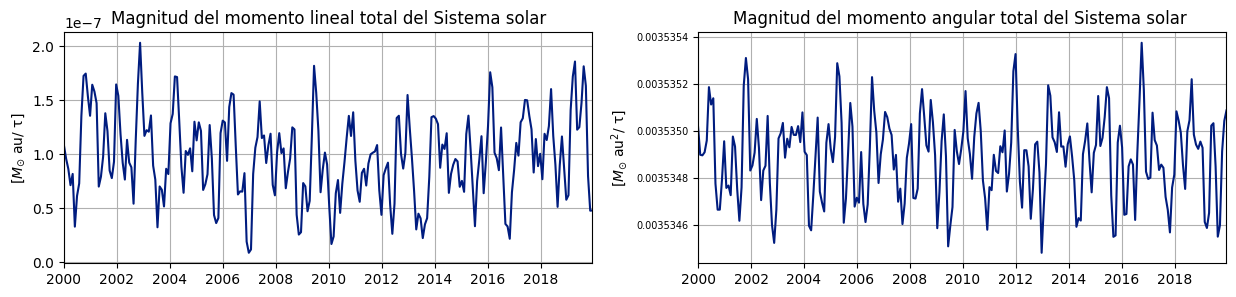

In [ ]:
# magnitud del momento lineal
P_mag = np.linalg.norm(Pt, axis=1)
L_mag = np.linalg.norm(Lt, axis=1)

fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(15,3))
# Magnitud P
ax[0].set_title('Magnitud del momento lineal total del Sistema solar')
ax[0].plot(t, P_mag)
ax[0].set_ylabel('[$M_{\odot}$ au/ τ]')
ax[0].set_xlim(t[0], t[-1])
ax[0].grid()
# Magnitud L
ax[1].set_title('Magnitud del momento angular total del Sistema solar ')
ax[1].plot(t, L_mag)
ax[1].set_ylabel('[$M_{\odot}$ au$^{2}$/ τ]')
ax[1].set_xlim(t[0], t[-1])
ax[1].grid()
ax[1].tick_params(axis='y', labelsize=7)

A pesar de tener una apariencia de ruido presente, las magnitudes estan siempre centradas, o tienden a estarlo en un valor constante, sin alejarse demasiado de tal valor.